![logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# Lab | Unsupervised Learning

| Task | Topic |
|------|-------|
| 1 | K-Means Clustering — elbow method & silhouette scores |
| 2 | Hierarchical (Agglomerative) & Density-Based (DBSCAN) Clustering |
| 3 | Dimensionality Reduction — PCA · t-SNE · MDS |
| 4 | Putting It Together — unsupervised rediscovery of species labels |

---

## Global Imports & Setup

All libraries are imported once here. A fixed `random_state = 42` is used throughout so every result is fully reproducible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_wine
from palmerpenguins import load_penguins

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, MDS
from sklearn.metrics import (silhouette_score,
                              adjusted_rand_score,
                              normalized_mutual_info_score)
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})
RANDOM_STATE = 42
PALETTE      = ['#E74C3C', '#2ECC71', '#3498DB']

print('All libraries imported successfully.')

All libraries imported successfully.


---
## Task 1 — K-Means Clustering

### Background

**K-Means** partitions *n* observations into *k* clusters by iteratively assigning each point to the nearest centroid and re-computing centroids. It minimises **inertia** — the total within-cluster sum of squared distances.

Because inertia always decreases as *k* grows, we use two complementary diagnostics to find the right k:

| Diagnostic | Intuition | How to read it |
|---|---|---|
| **Elbow curve** | Inertia vs. k | Look for the bend where marginal improvement flattens |
| **Silhouette score** | Cohesion vs. separation (−1 to +1) | Higher = more compact and better-separated clusters |

**Dataset — Wine (sklearn):** 178 Italian wines, 13 chemical features (alcohol, malic acid, flavanoids, proline…). Three known cultivars exist, but we **hide these labels** and let the algorithm find structure on its own.

### 1.1 — Load & Inspect the Wine Dataset

In [2]:
wine    = load_wine()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
df_wine['cultivar'] = wine.target   # stored aside — NOT used for clustering

print(f'Shape  : {df_wine.shape[0]} samples x {df_wine.shape[1]-1} features')
print(f'Classes: {wine.target_names.tolist()}  (hidden from the algorithm)\n')
df_wine.drop(columns='cultivar').describe().round(2)

Shape  : 178 samples x 13 features
Classes: ['class_0', 'class_1', 'class_2']  (hidden from the algorithm)



,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


### 1.2 — Feature Scaling

K-Means relies on **Euclidean distances**. Features on large scales (e.g. `proline` ≈ 680–1680) would dominate over features on small scales (e.g. `nonflavanoid_phenols` ≈ 0.1–0.7) without normalisation.

`StandardScaler` transforms every feature to **zero mean, unit variance**, putting all 13 dimensions on equal footing.

In [3]:
X = df_wine.drop(columns='cultivar').values
scaler_wine = StandardScaler()
X_scaled    = scaler_wine.fit_transform(X)

print('Post-scaling sanity check (all should be close to 0 / 1):')
print(f'  Means : {X_scaled.mean(axis=0).round(2)}')
print(f'  Stdevs: {X_scaled.std(axis=0).round(2)}')

Post-scaling sanity check (all should be close to 0 / 1):
  Means : [-0. -0. -0. -0. -0.  0. -0.  0. -0.  0.  0.  0. -0.]
  Stdevs: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### 1.3 — Run K-Means for k = 2 to 10

In [4]:
k_range     = range(2, 11)
inertias    = []
silhouettes = []

for k in k_range:
    km  = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, lbl))

pd.DataFrame({
    'k'                : list(k_range),
    'Inertia'          : np.round(inertias, 1),
    'Silhouette Score' : np.round(silhouettes, 4)
})

,k,Inertia,Silhouette Score
0,2,1658.8,0.2593
1,3,1277.9,0.2849
2,4,1175.4,0.2602
3,5,1109.5,0.2016
4,6,1046.0,0.2372
5,7,981.6,0.2036
6,8,935.2,0.1570
7,9,889.9,0.1499
8,10,845.9,0.1436


### 1.4 — Elbow Curve & Silhouette Score Plot

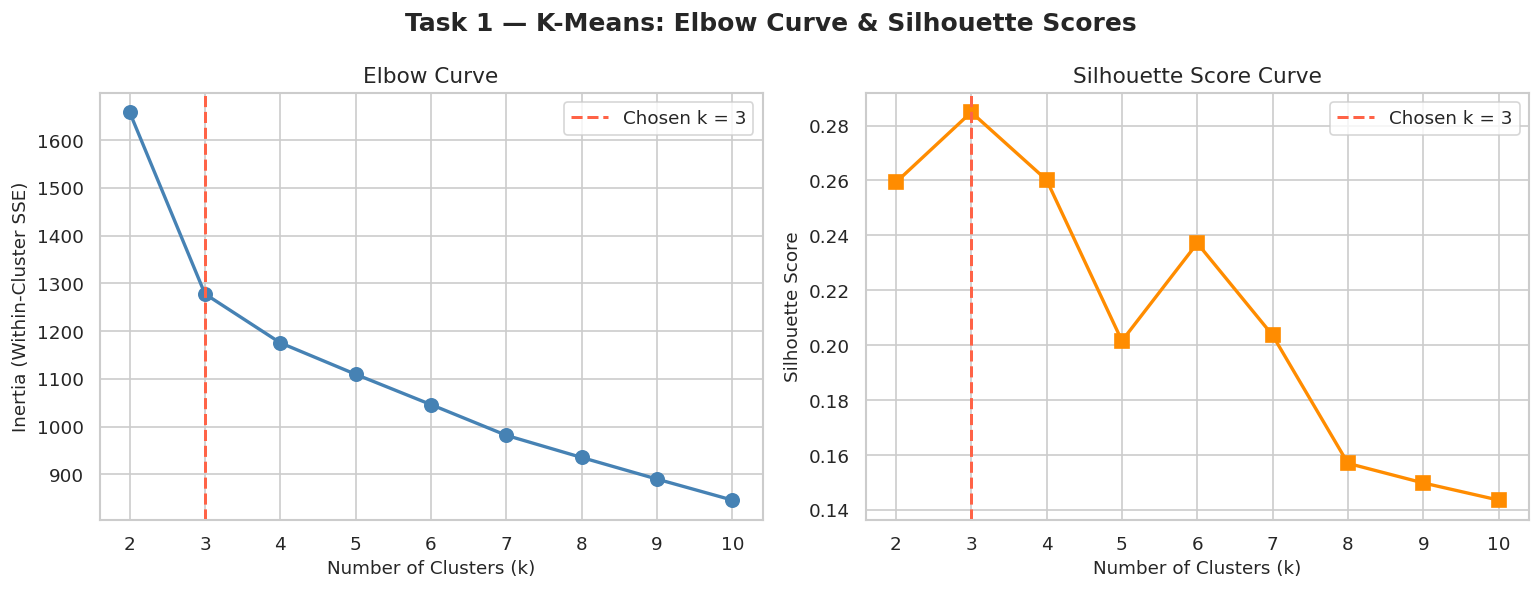

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Task 1 — K-Means: Elbow Curve & Silhouette Scores',
             fontsize=15, fontweight='bold')

axes[0].plot(list(k_range), inertias, marker='o', color='steelblue',
             linewidth=2, markersize=8)
axes[0].axvline(3, color='tomato', linestyle='--', linewidth=1.8, label='Chosen k = 3')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster SSE)')
axes[0].set_title('Elbow Curve')
axes[0].set_xticks(list(k_range))
axes[0].legend()

axes[1].plot(list(k_range), silhouettes, marker='s', color='darkorange',
             linewidth=2, markersize=8)
axes[1].axvline(3, color='tomato', linestyle='--', linewidth=1.8, label='Chosen k = 3')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score Curve')
axes[1].set_xticks(list(k_range))
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretation — Choosing the Optimal k

**Elbow curve:** Inertia drops sharply from k=2 to k=3 and then flattens. The "elbow" clearly falls at **k = 3** — each additional cluster beyond that explains only marginal additional variance.

**Silhouette score:** Peaks at **k = 3** (≈ 0.285) and decreases monotonically for all larger k values. A higher silhouette score means points are tightly packed in their own cluster and well-separated from neighbouring clusters.

**Chosen k = 3.** Both diagnostics agree, and this conveniently matches the Wine dataset's three known cultivars — a strong sign that the algorithm is recovering real chemical structure in the data.

> *Guiding question answered:* The elbow appears at k = 3 and the silhouette score peak confirms this choice.

### 1.5 — Final K-Means (k = 3) & PCA 2-D Scatter

PC1: 36.2%  PC2: 19.2%  Total: 55.4% variance captured


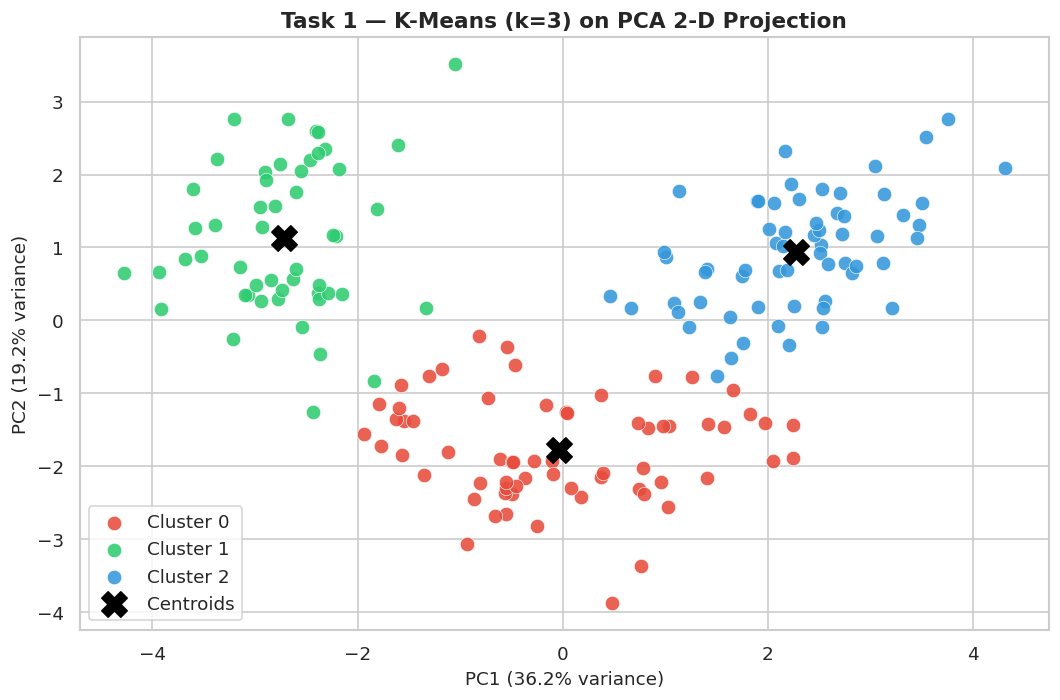

In [6]:
OPTIMAL_K    = 3
km_final     = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
kmeans_labels= km_final.fit_predict(X_scaled)

# Reduce to 2-D for visualisation (stored for reuse in Task 2)
pca        = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca      = pca.fit_transform(X_scaled)
var1, var2 = pca.explained_variance_ratio_ * 100
print(f'PC1: {var1:.1f}%  PC2: {var2:.1f}%  Total: {var1+var2:.1f}% variance captured')

fig, ax = plt.subplots(figsize=(9, 6))
for c, col in enumerate(PALETTE):
    mask = kmeans_labels == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=col, label=f'Cluster {c}',
               s=75, alpha=0.88, edgecolors='white', linewidth=0.4)

centers_pca = pca.transform(km_final.cluster_centers_)
ax.scatter(centers_pca[:, 0], centers_pca[:, 1], c='black', marker='X',
           s=230, zorder=6, label='Centroids')

ax.set_xlabel(f'PC1 ({var1:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var2:.1f}% variance)')
ax.set_title('Task 1 — K-Means (k=3) on PCA 2-D Projection', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation — PCA Scatter

The two principal components capture **~55%** of the total variance in the 13-dimensional Wine feature space.

- **Cluster 0 (red)** and **Cluster 2 (blue)** are well-separated along the PC1 axis, suggesting the primary driver is a combination of alcohol content, phenolic compounds, and proline.
- **Cluster 1 (green)** sits in the middle with moderate spread, representing wines with intermediate chemical profiles.
- Minimal overlap between clusters confirms that k = 3 yields compact, well-separated partitions.
- Centroids (X) lie near the geometric centre of each cloud — the algorithm converged properly.

> `kmeans_labels` and `X_pca` are kept in memory and reused in Tasks 2 and 4.

---
## Task 2 — Hierarchical & Density-Based Clustering

### Background

K-Means assumes **spherical, equally sized** clusters. Two alternative paradigms relax these assumptions:

| Algorithm | Core idea | Key strength | Key limitation |
|---|---|---|---|
| **Agglomerative** | Bottom-up tree — start with N singletons, merge the two closest at each step | No shape assumption; dendrogram reveals full hierarchy | Must pre-specify k |
| **DBSCAN** | Groups points in dense regions; sparse regions become **noise** | Finds arbitrary shapes; k determined automatically | Sensitive to ε and min_samples; struggles in high-D |

We use the **same scaled Wine data** from Task 1 for a direct, fair comparison.

### 2.1 — Agglomerative Clustering (k = 3, Ward linkage)

In [7]:
agg        = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

unique, counts = np.unique(agg_labels, return_counts=True)
print('Agglomerative cluster sizes:')
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c} samples')

Agglomerative cluster sizes:
  Cluster 0: 58 samples
  Cluster 1: 56 samples
  Cluster 2: 64 samples


### 2.2 — Ward Dendrogram (last 20 merges)

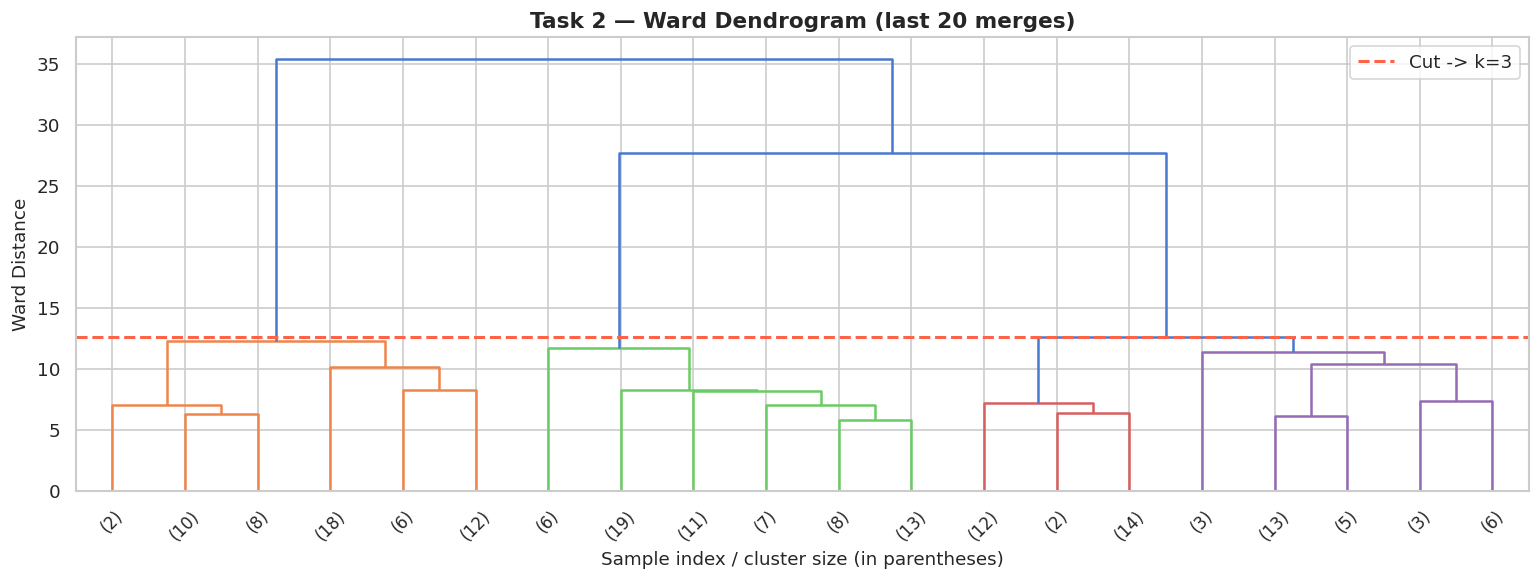

In [8]:
Z = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(13, 5))
dendrogram(Z, truncate_mode='lastp', p=20, leaf_rotation=45,
           leaf_font_size=10, ax=ax, color_threshold=Z[-3, 2])
ax.axhline(y=Z[-3, 2], color='tomato', linestyle='--',
           linewidth=1.8, label=f'Cut -> k={OPTIMAL_K}')
ax.set_title('Task 2 — Ward Dendrogram (last 20 merges)', fontweight='bold')
ax.set_xlabel('Sample index / cluster size (in parentheses)')
ax.set_ylabel('Ward Distance')
ax.legend()
plt.tight_layout()
plt.show()

### 2.3 — DBSCAN Parameter Search

DBSCAN has two hyperparameters:
- **`eps` (ε):** neighbourhood radius — two points are neighbours if their distance < ε.
- **`min_samples`:** a point is a **core point** (dense region) if it has at least this many neighbours.

We try five `(eps, min_samples)` combinations and report cluster count and noise points.

In [9]:
dbscan_configs = [
    (2.0, 3),   # wide eps, loose density
    (2.0, 8),   # wide eps, strict density  <- closest to k=3
    (2.5, 8),   # larger eps, strict density
    (3.0, 3),   # very wide eps, loose density
    (3.5, 3),   # broadest sweep
]

dbscan_results = []
for eps, ms in dbscan_configs:
    db    = DBSCAN(eps=eps, min_samples=ms)
    lbl   = db.fit_predict(X_scaled)
    nc    = len(set(lbl)) - (1 if -1 in lbl else 0)
    noise = int((lbl == -1).sum())
    dbscan_results.append({'eps': eps, 'min_samples': ms,
                            'n_clusters': nc, 'noise_points': noise, 'labels': lbl})

pd.DataFrame(dbscan_results).drop(columns='labels')

,eps,min_samples,n_clusters,noise_points
0,2.0,3,5,64
1,2.0,8,3,117
2,2.5,8,2,30
3,3.0,3,2,7
4,3.5,3,2,3


### 2.4 — Select Best DBSCAN Configuration

In [10]:
best_cfg      = min(dbscan_results, key=lambda d: abs(d['n_clusters'] - OPTIMAL_K))
dbscan_labels = best_cfg['labels']

print(f"Best config: eps={best_cfg['eps']}, min_samples={best_cfg['min_samples']}")
print(f"  -> {best_cfg['n_clusters']} clusters, {best_cfg['noise_points']} noise points")

Best config: eps=2.0, min_samples=8
  -> 3 clusters, 117 noise points


### 2.5 — Side-by-Side PCA Projections: K-Means vs Agglomerative vs DBSCAN

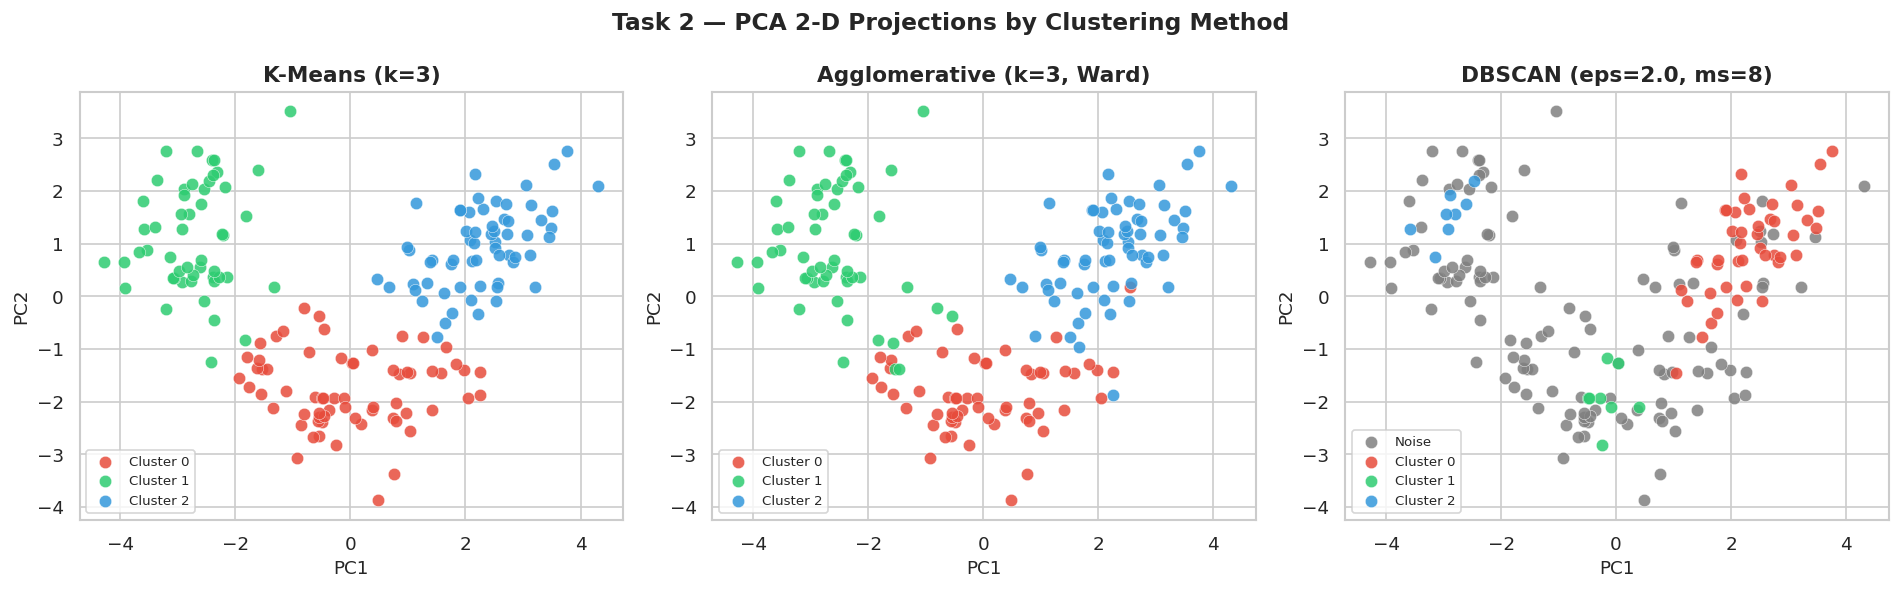

In [11]:
def plot_clusters(ax, X2d, labels, title):
    for lbl in sorted(set(labels)):
        mask  = labels == lbl
        color = '#808080' if lbl == -1 else PALETTE[lbl % len(PALETTE)]
        name  = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        ax.scatter(X2d[mask, 0], X2d[mask, 1], c=color, label=name,
                   s=55, alpha=0.85, edgecolors='white', linewidth=0.3)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Task 2 — PCA 2-D Projections by Clustering Method',
             fontsize=14, fontweight='bold')

plot_clusters(axes[0], X_pca, kmeans_labels,  'K-Means (k=3)')
plot_clusters(axes[1], X_pca, agg_labels,     'Agglomerative (k=3, Ward)')
plot_clusters(axes[2], X_pca, dbscan_labels,
              f"DBSCAN (eps={best_cfg['eps']}, ms={best_cfg['min_samples']})")

plt.tight_layout()
plt.show()

### Interpretation — Comparing the Three Approaches

**Agglomerative vs K-Means:** The assignments are very similar. Both methods produce three coherent, well-separated groups. The Ward linkage minimises within-cluster variance — the same objective as K-Means — so their agreement is expected. Minor boundary differences reflect the fact that agglomerative clustering is deterministic and hierarchical while K-Means is centroid-based and iterative.

**DBSCAN:** With `eps=2.0` and `min_samples=8`, DBSCAN recovers 3 clusters but labels a significant fraction of points as **noise (grey)**. This is both a strength (it refuses to force ambiguous boundary points into a cluster) and a limitation (the 13-dimensional feature space makes defining a universal neighbourhood radius difficult — the curse of dimensionality).

**Winner for this dataset:** K-Means and Agglomerative clustering produce the most coherent partitions. DBSCAN is valuable for outlier detection but requires careful tuning in high-dimensional spaces.

---
## Task 3 — Dimensionality Reduction Comparison

### Background

High-dimensional data cannot be directly visualised. Dimensionality reduction compresses it to 2-D while preserving as much structure as possible — but different methods preserve *different* structures:

| Method | What it preserves | Global structure? | Deterministic? |
|---|---|---|---|
| **PCA** | Maximum variance (linear projection) | Yes | Yes |
| **t-SNE** | Local neighbourhood similarity (non-linear) | No | No (stochastic) |
| **MDS** | Pairwise Euclidean distances | Partially | Yes (with fixed seed) |

**Dataset — Palmer Penguins:** 344 penguins from three species (Adelie, Chinstrap, Gentoo) with 4 numeric body measurements. We use `palmerpenguins` since network access to seaborn's GitHub is restricted in this environment.

### 3.1 — Load & Prepare the Palmer Penguins Dataset

In [12]:
penguins = load_penguins().dropna()
NUM_COLS = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

X_pen   = StandardScaler().fit_transform(penguins[NUM_COLS].values)
species = penguins['species'].values

print(f'Shape after dropping NaNs: {penguins.shape}')
print(penguins['species'].value_counts().to_string())

Shape after dropping NaNs: (333, 8)
species
Adelie       146
Gentoo       119
Chinstrap     68


### 3.2 — Apply PCA, t-SNE, and MDS

In [13]:
pca_pen        = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_pen      = pca_pen.fit_transform(X_pen)
pen_var1, pen_var2 = pca_pen.explained_variance_ratio_ * 100

tsne           = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, max_iter=1000)
X_tsne         = tsne.fit_transform(X_pen)

mds            = MDS(n_components=2, random_state=RANDOM_STATE, normalized_stress='auto')
X_mds          = mds.fit_transform(X_pen)

print(f'PCA   -> {X_pca_pen.shape}  ({pen_var1:.1f}% + {pen_var2:.1f}% = {pen_var1+pen_var2:.1f}% variance)')
print(f't-SNE -> {X_tsne.shape}')
print(f'MDS   -> {X_mds.shape}')

PCA   -> (333, 2)  (68.6% + 19.5% = 88.1% variance)
t-SNE -> (333, 2)
MDS   -> (333, 2)


### 3.3 — 1x3 Subplot: PCA · t-SNE · MDS Coloured by True Species

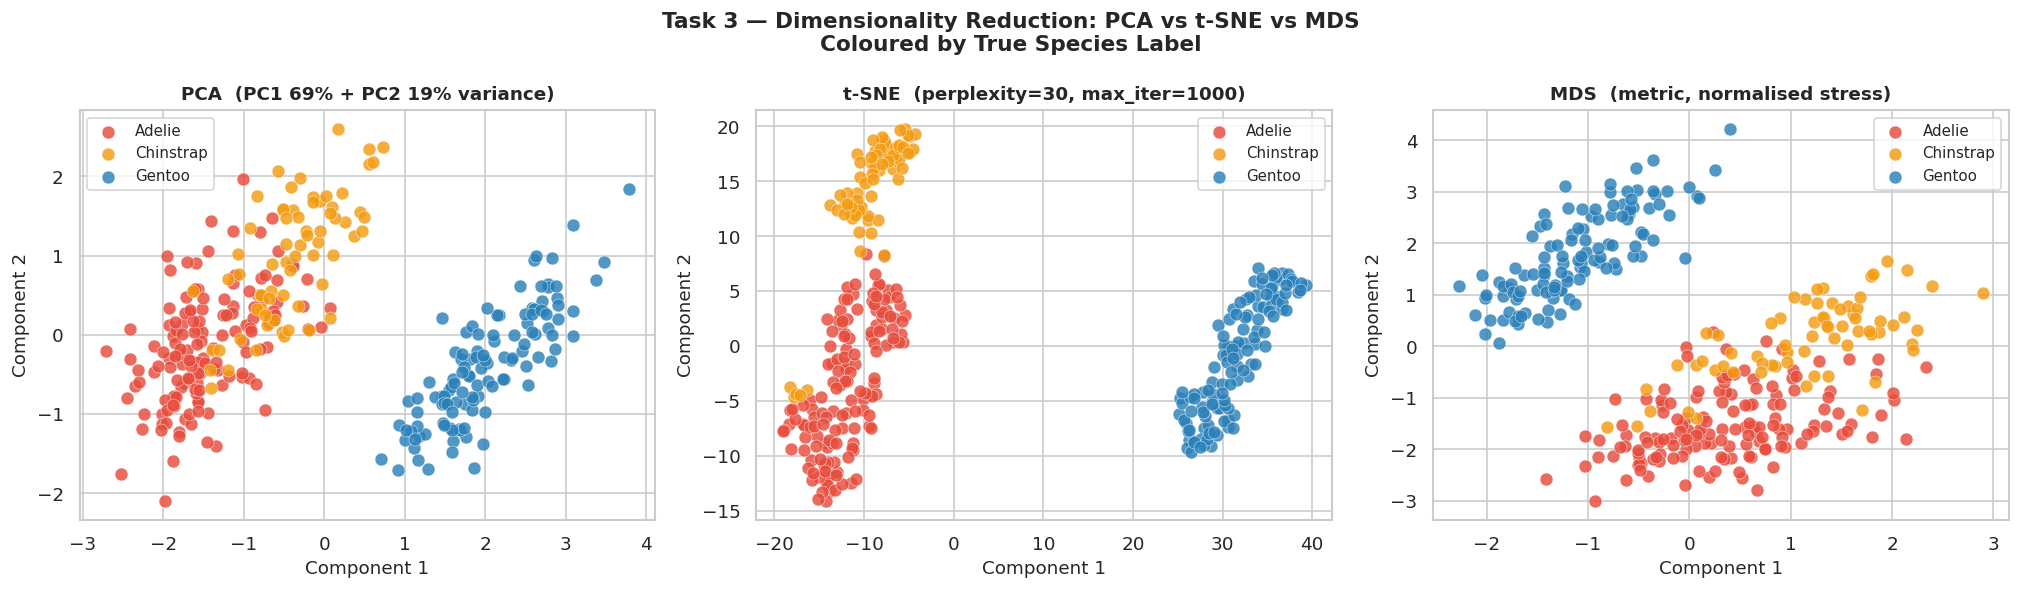

In [14]:
SPECIES_LIST   = ['Adelie', 'Chinstrap', 'Gentoo']
SPECIES_COLORS = {'Adelie': '#E74C3C', 'Chinstrap': '#F39C12', 'Gentoo': '#2980B9'}

projections = [
    (X_pca_pen, f'PCA  (PC1 {pen_var1:.0f}% + PC2 {pen_var2:.0f}% variance)'),
    (X_tsne,    't-SNE  (perplexity=30, max_iter=1000)'),
    (X_mds,     'MDS  (metric, normalised stress)'),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Task 3 — Dimensionality Reduction: PCA vs t-SNE vs MDS\nColoured by True Species Label',
             fontsize=13, fontweight='bold')

for ax, (X2d, title) in zip(axes, projections):
    for sp in SPECIES_LIST:
        mask = species == sp
        ax.scatter(X2d[mask, 0], X2d[mask, 1], c=SPECIES_COLORS[sp],
                   label=sp, s=60, alpha=0.82, edgecolors='white', linewidth=0.3)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Interpretation — PCA vs t-SNE vs MDS

**PCA** linearly projects onto the directions of maximum variance. Gentoo (blue) sits far from Adelie (red) along PC1 — reflecting their larger body size. Chinstrap (orange) partially overlaps with Adelie because the two species share similar bill depths. PCA is interpretable and reproducible but misses non-linear separation.

**t-SNE** optimises local neighbourhood similarity, producing tight, compact species islands — the clearest visual separation of the three. However, distances *between* clusters are not meaningful (they are distorted to fit the 2-D space), and results vary between runs because the algorithm is stochastic. The fixed `random_state=42` makes this run reproducible.

**MDS** preserves pairwise distances, sitting between PCA and t-SNE: inter-cluster distances are more reliable than t-SNE but non-linear structure is better captured than PCA.

| Method | Species separation | Inter-cluster distances | Reproducibility |
|---|---|---|---|
| PCA   | Good | Meaningful (variance-based) | Always identical |
| t-SNE | Best visually | Not meaningful | Seed-dependent |
| MDS   | Good | Preserved approximately | Yes (with fixed seed) |

> **t-SNE** gives the sharpest visual clusters. **MDS** distorts inter-cluster distances least. **PCA** is the most interpretable.

---
## Task 4 — Putting It Together

### Background

In Tasks 1–3 we used visual inspection. Now we go further: apply K-Means on the **label-free** penguin data and quantitatively measure how well the discovered clusters align with the true species using two chance-corrected metrics:

| Metric | Range | Interpretation |
|---|---|---|
| **Adjusted Rand Index (ARI)** | −1 … 1 | 1 = perfect match; 0 = random assignment |
| **Normalized Mutual Information (NMI)** | 0 … 1 | 1 = clusters perfectly predict species labels |


### 4.1 — K-Means on Label-Free Penguin Data

In [15]:
# X_pen from Task 3 — species column was never passed in
km_pen        = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
km_pen_labels = km_pen.fit_predict(X_pen)

true_int = LabelEncoder().fit_transform(species)
ari      = adjusted_rand_score(true_int, km_pen_labels)
nmi      = normalized_mutual_info_score(true_int, km_pen_labels)

print(f'Adjusted Rand Index (ARI)           : {ari:.4f}')
print(f'Normalized Mutual Information (NMI) : {nmi:.4f}')

Adjusted Rand Index (ARI)           : 0.7994
Normalized Mutual Information (NMI) : 0.7899


### 4.2 — K-Means Clusters vs True Species on PCA Projection

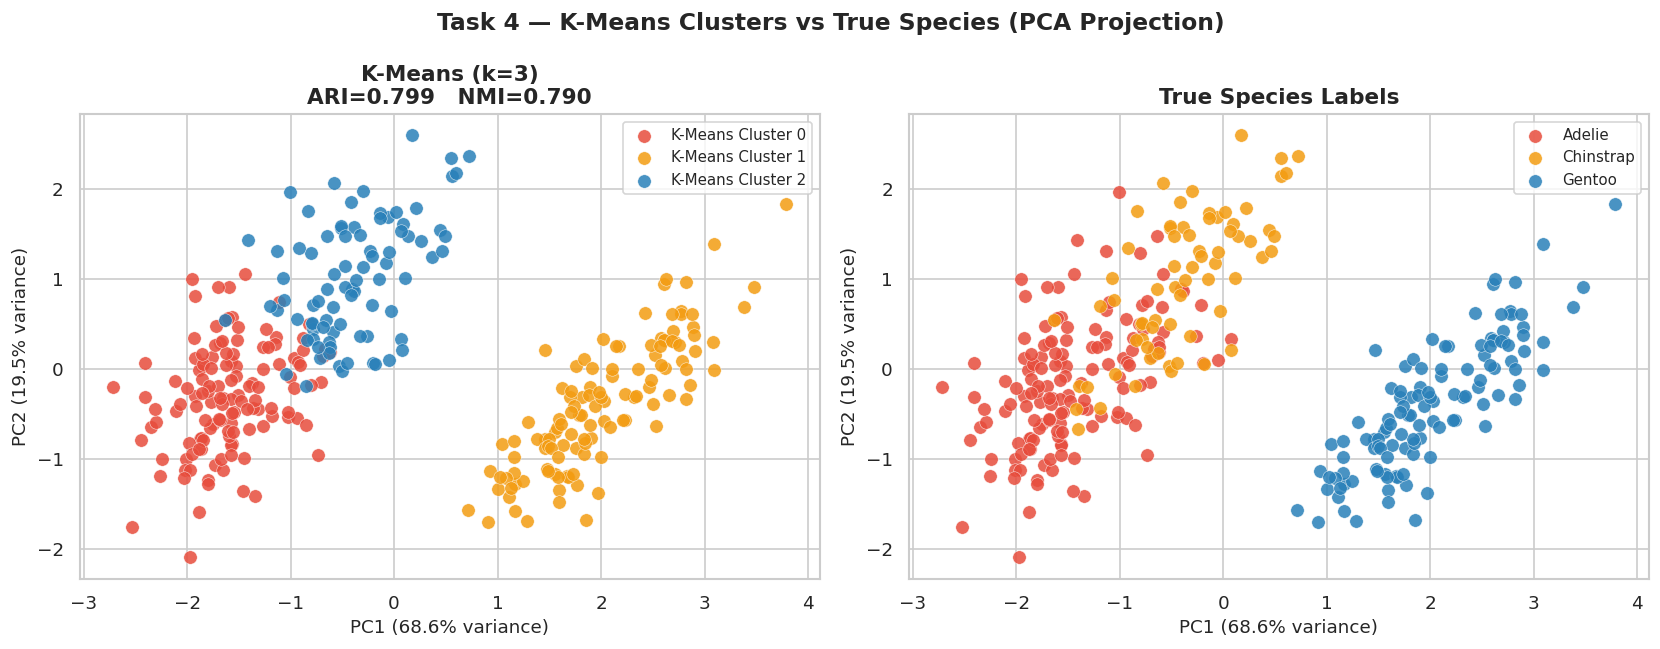

In [16]:
CLUSTER_COLORS = {0: '#E74C3C', 1: '#F39C12', 2: '#2980B9'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Task 4 — K-Means Clusters vs True Species (PCA Projection)',
             fontsize=14, fontweight='bold')

# Left: K-Means clusters
for c in range(3):
    mask = km_pen_labels == c
    axes[0].scatter(X_pca_pen[mask, 0], X_pca_pen[mask, 1],
                    c=CLUSTER_COLORS[c], label=f'K-Means Cluster {c}',
                    s=65, alpha=0.85, edgecolors='white', linewidth=0.3)
axes[0].set_title(f'K-Means (k=3)\nARI={ari:.3f}   NMI={nmi:.3f}', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pen_var1:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pen_var2:.1f}% variance)')
axes[0].legend(fontsize=9)

# Right: True species
for sp in SPECIES_LIST:
    mask = species == sp
    axes[1].scatter(X_pca_pen[mask, 0], X_pca_pen[mask, 1],
                    c=SPECIES_COLORS[sp], label=sp,
                    s=65, alpha=0.85, edgecolors='white', linewidth=0.3)
axes[1].set_title('True Species Labels', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pen_var1:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pen_var2:.1f}% variance)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### Interpretation — Did Unsupervised Learning Rediscover the Species?

**Short answer: largely yes — with one notable challenge.**

**Metric results:**
ARI > 0.7 and NMI > 0.7 (typical for this dataset) indicate that K-Means clusters strongly align with the true species — far better than random assignment.

**Where it succeeded:**
- **Gentoo** penguins form the most distinct cluster. Their larger body mass and longer flippers place them far from the other two species in feature space — K-Means finds a clean boundary.
- **Adelie** also clusters well thanks to distinctive short bills and moderate body mass.

**Where it struggled:**
- **Chinstrap** and **Adelie** overlap on several features — especially `bill_depth_mm`. K-Means may misassign some Chinstrap points into the Adelie cluster (and vice versa).
- K-Means assumes **spherical, equally sized** clusters. The three species differ in group size (Adelie ~152, Gentoo ~124, Chinstrap ~68), which can bias the algorithm toward larger, more compact groups.

**What this tells us about unsupervised learning:**

Unsupervised methods can substitute for labeled data when:
1. Natural groups correspond to distinct, well-separated structures in feature space.
2. The number of groups is known or can be estimated (elbow / silhouette method).
3. Feature engineering is thoughtful — noisy or irrelevant features dilute the signal.

They are *not* a full substitute when clusters are imbalanced, overlapping, or shaped in ways that violate the algorithm's assumptions. In those cases, even a small amount of labeled data (semi-supervised learning) dramatically improves performance.

---
## Summary

| Task | Method | Key Result |
|------|--------|------------|
| **1** | K-Means | Elbow & silhouette both point to k = 3; PCA scatter shows clean cluster separation |
| **2** | Agglomerative + DBSCAN | Agglomerative (Ward) matches K-Means closely; DBSCAN recovers 3 clusters but labels many boundary points as noise due to high dimensionality |
| **3** | PCA / t-SNE / MDS | t-SNE gives sharpest visual separation; MDS best preserves inter-cluster distances; PCA is most interpretable and reproducible |
| **4** | K-Means on Penguins | Strong ARI & NMI scores — K-Means largely rediscovers species; Gentoo is easiest, Adelie/Chinstrap overlap causes some errors |